<a href="https://colab.research.google.com/github/renataazzahra/Data-Mining/blob/main/Klasterisasi_Indonesia_Emas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sb

import matplotlib.pyplot as plt


*   RLS = Rata rata lama sekolah
*   UHH = Umur Harapan Hidup
*   Kepadatan = Kepadatan penduduk per km^2
*   Internet = Persentase Rumah Tangga yang Pernah Mengakses Internet
*   TPT = Tingkat Pengangguran Terbuka
*   IKK = Indeks Keparahan Kemiskinan

In [ ]:
data =  pd.read_excel('/content/sample_data/Lomba Datmin.xlsx')
data

,Provinsi/Kabupaten/Kota/Indonesia,RLS,UHH,Kepadatan,internet,TPT,IKK
0,ACEH,9.95,73.48,99,88.95,5.64,0.52
1,SUMATERA UTARA,10.08,74.19,218,92.30,5.32,0.19
2,RIAU,9.55,74.74,76,94.16,4.16,0.15
3,JAMBI,8.95,74.39,77,90.59,4.26,0.15
4,SUMATERA SELATAN,8.91,74.58,103,90.94,3.69,0.38
5,BENGKULU,9.23,73.59,106,90.62,3.41,0.32
6,LAMPUNG,8.61,74.71,284,91.57,4.21,0.24
7,KEP. BANGKA BELITUNG,8.65,74.46,93,92.14,4.45,0.15
8,KEPULAUAN RIAU,10.72,75.46,268,97.57,6.45,0.15
9,DKI JAKARTA,11.59,76.27,16155,98.18,6.05,0.10


# Pre Processing

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Provinsi/Kabupaten/Kota/Indonesia  37 non-null     object 
 1   RLS                                37 non-null     float64
 2   UHH                                37 non-null     float64
 3   Kepadatan                          37 non-null     int64  
 4   internet                           37 non-null     float64
 5   TPT                                37 non-null     float64
 6   IKK                                37 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 2.2+ KB


In [ ]:
data.isnull().sum()

,0
Provinsi/Kabupaten/Kota/Indonesia,0
RLS,0
UHH,0
Kepadatan,0
internet,0
TPT,0
IKK,0


Tidak terdapat missing value, sehingga bisa dilanjukan ke langkah berikutnya.

# Standarisasi

Standarisasi dilakukan untuk menyamakan skala variabel serta mencegah dominasi variabel besar.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
df = data.drop('Provinsi/Kabupaten/Kota/Indonesia', axis = 1)
df

,RLS,UHH,Kepadatan,internet,TPT,IKK
0,9.95,73.48,99,88.95,5.64,0.52
1,10.08,74.19,218,92.30,5.32,0.19
2,9.55,74.74,76,94.16,4.16,0.15
3,8.95,74.39,77,90.59,4.26,0.15
4,8.91,74.58,103,90.94,3.69,0.38
5,9.23,73.59,106,90.62,3.41,0.32
6,8.61,74.71,284,91.57,4.21,0.24
7,8.65,74.46,93,92.14,4.45,0.15
8,10.72,75.46,268,97.57,6.45,0.15
9,11.59,76.27,16155,98.18,6.05,0.10


In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [ ]:
df = pd.DataFrame(df_scaled, columns = df.columns)
df

,RLS,UHH,Kepadatan,internet,TPT,IKK
0,0.762326,0.147564,-0.228610,0.177106,0.879437,0.084971
1,0.867694,0.454980,-0.182952,0.386954,0.645500,-0.536284
2,0.438119,0.693119,-0.237434,0.503467,-0.202521,-0.611588
3,-0.048193,0.541576,-0.237051,0.279837,-0.129416,-0.611588
4,-0.080614,0.623842,-0.227075,0.301762,-0.546116,-0.178592
5,0.178752,0.195192,-0.225924,0.281717,-0.750811,-0.291547
6,-0.323770,0.680130,-0.157629,0.341226,-0.165969,-0.442155
7,-0.291349,0.571885,-0.230912,0.376931,0.009484,-0.611588
8,1.386426,1.004865,-0.163768,0.717073,1.471590,-0.611588
9,2.091578,1.355579,5.931724,0.755285,1.179168,-0.705718


# Clustering

In [ ]:
inertia=[]

In [ ]:
from sklearn.cluster import KMeans

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(df_scaled)

    inertia.append(kmeans.inertia_)

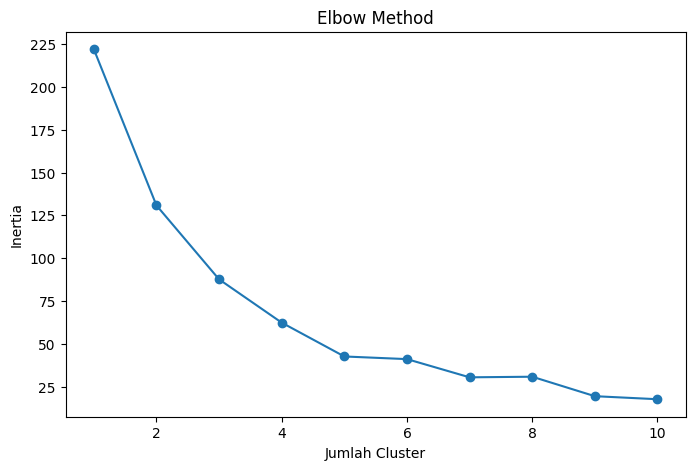

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')

plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(df_scaled)

    score = silhouette_score(
        df_scaled,
        labels
    )

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.6751
K = 3, Silhouette Score = 0.6570
K = 4, Silhouette Score = 0.4094
K = 5, Silhouette Score = 0.3612
K = 6, Silhouette Score = 0.2551
K = 7, Silhouette Score = 0.3250
K = 8, Silhouette Score = 0.2217
K = 9, Silhouette Score = 0.2915
K = 10, Silhouette Score = 0.2731


Berdasarkan hasil evaluasi menggunakan Silhouette Score, nilai tertinggi diperoleh pada K=2 sebesar 0,6751. Namun, nilai Silhouette Score pada K=3 sebesar 0,6570 tidak berbeda jauh dan masih berada pada kategori baik. Oleh karena itu, penelitian ini menggunakan K=3 karena mampu memberikan segmentasi wilayah yang lebih informatif dan relevan untuk analisis kebijakan dibandingkan K=2.

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmeans = KMeans(n_clusters= 3, random_state=42)
kmeans.fit(df_scaled)

KMeans(n_clusters=3, random_state=42)

In [ ]:
kmeans.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], dtype=int32)

In [ ]:
data['Cluster'] = kmeans.labels_
data

,Provinsi/Kabupaten/Kota/Indonesia,RLS,UHH,Kepadatan,internet,TPT,IKK,Cluster
0,ACEH,9.95,73.48,99,88.95,5.64,0.52,0
1,SUMATERA UTARA,10.08,74.19,218,92.30,5.32,0.19,0
2,RIAU,9.55,74.74,76,94.16,4.16,0.15,0
3,JAMBI,8.95,74.39,77,90.59,4.26,0.15,0
4,SUMATERA SELATAN,8.91,74.58,103,90.94,3.69,0.38,0
5,BENGKULU,9.23,73.59,106,90.62,3.41,0.32,0
6,LAMPUNG,8.61,74.71,284,91.57,4.21,0.24,0
7,KEP. BANGKA BELITUNG,8.65,74.46,93,92.14,4.45,0.15,0
8,KEPULAUAN RIAU,10.72,75.46,268,97.57,6.45,0.15,0
9,DKI JAKARTA,11.59,76.27,16155,98.18,6.05,0.10,2


In [ ]:
data[['Provinsi/Kabupaten/Kota/Indonesia', 'Cluster']]

,Provinsi/Kabupaten/Kota/Indonesia,Cluster
0,ACEH,0
1,SUMATERA UTARA,0
2,RIAU,0
3,JAMBI,0
4,SUMATERA SELATAN,0
5,BENGKULU,0
6,LAMPUNG,0
7,KEP. BANGKA BELITUNG,0
8,KEPULAUAN RIAU,0
9,DKI JAKARTA,2


In [ ]:
scaled_cluster = pd.DataFrame(df_scaled.copy(), columns=df.columns)
scaled_cluster['Cluster'] = data['Cluster']

In [ ]:
cluster_size = scaled_cluster.groupby(['Cluster'], as_index=False).size()
cluster_size['Percentage'] = cluster_size['size'] / sum(cluster_size['size'])
cluster_size

,Cluster,size,Percentage
0,0,34,0.918919
1,1,2,0.054054
2,2,1,0.027027


In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(df_scaled)

In [ ]:
pca_df = pd.DataFrame(
    data=pca_result,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = data['Cluster']
pca_df['Provinsi/Kabupaten/Kota/Indonesia'] = data['Provinsi/Kabupaten/Kota/Indonesia']

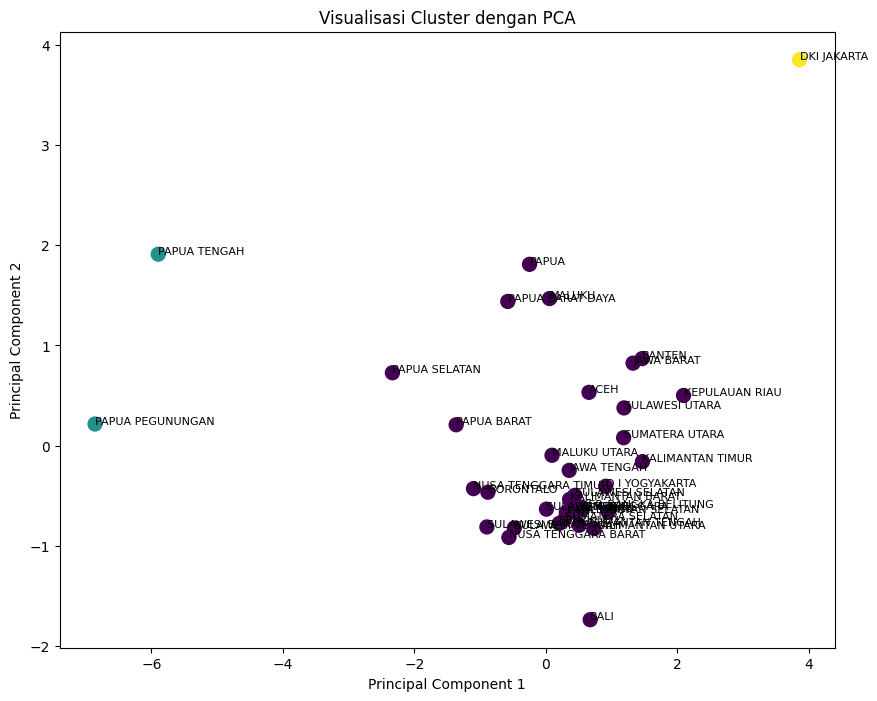

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['Cluster'],
    s=100
)

for i in range(len(pca_df)):
    plt.text(
        pca_df['PC1'][i],
        pca_df['PC2'][i],
        pca_df['Provinsi/Kabupaten/Kota/Indonesia'][i],
        fontsize=8
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title('Visualisasi Cluster dengan PCA')

plt.show()

In [ ]:
cluster_mean = data.drop(columns=['Provinsi/Kabupaten/Kota/Indonesia']).groupby('Cluster').mean()

print(cluster_mean)

               RLS        UHH     Kepadatan   internet       TPT       IKK
Cluster                                                                   
0         9.156765  73.351471    279.441176  89.415588  4.494706  0.378529
1         5.215000  67.965000     26.500000  24.115000  2.650000  2.300000
2        11.590000  76.270000  16155.000000  98.180000  6.050000  0.100000


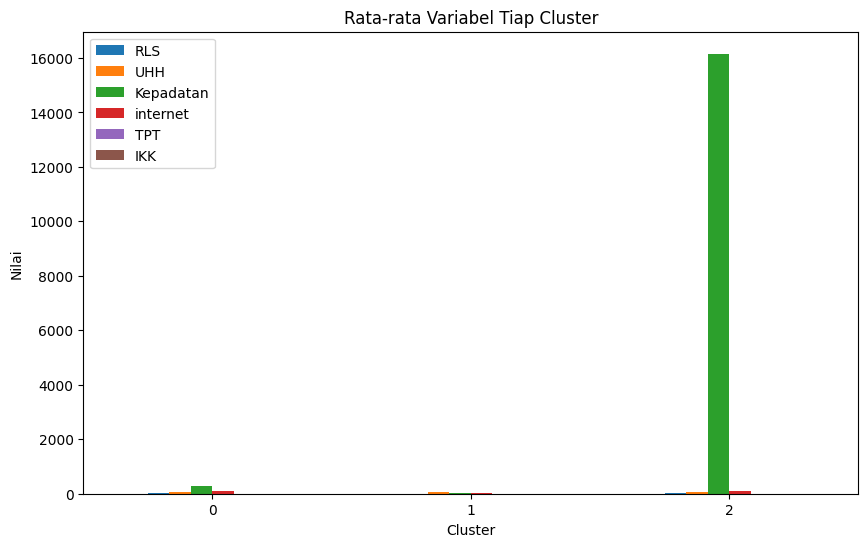

In [ ]:
cluster_mean.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Rata-rata Variabel Tiap Cluster')
plt.ylabel('Nilai')
plt.xticks(rotation=0)

plt.show()

# Visualisasi Masing-masing cluster

In [ ]:
scaled_cluster = pd.DataFrame(df_scaled.copy(), columns=df.columns)
scaled_cluster['Cluster'] = data['Cluster']
scaled_mean = scaled_cluster.groupby('Cluster').mean()

## Cluster 0 (Berkembang)

In [ ]:
cluster_0 = data[data['Cluster'] == 0]
cluster_0

,Provinsi/Kabupaten/Kota/Indonesia,RLS,UHH,Kepadatan,internet,TPT,IKK,Cluster
0,ACEH,9.95,73.48,99,88.95,5.64,0.52,0
1,SUMATERA UTARA,10.08,74.19,218,92.30,5.32,0.19,0
2,RIAU,9.55,74.74,76,94.16,4.16,0.15,0
3,JAMBI,8.95,74.39,77,90.59,4.26,0.15,0
4,SUMATERA SELATAN,8.91,74.58,103,90.94,3.69,0.38,0
5,BENGKULU,9.23,73.59,106,90.62,3.41,0.32,0
6,LAMPUNG,8.61,74.71,284,91.57,4.21,0.24,0
7,KEP. BANGKA BELITUNG,8.65,74.46,93,92.14,4.45,0.15,0
8,KEPULAUAN RIAU,10.72,75.46,268,97.57,6.45,0.15,0
10,JAWA BARAT,9.14,75.53,1370,90.58,6.77,0.27,0


In [ ]:
labels = scaled_mean.columns
values = scaled_mean.loc[0].values.flatten().tolist()
values += values[:1]

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]

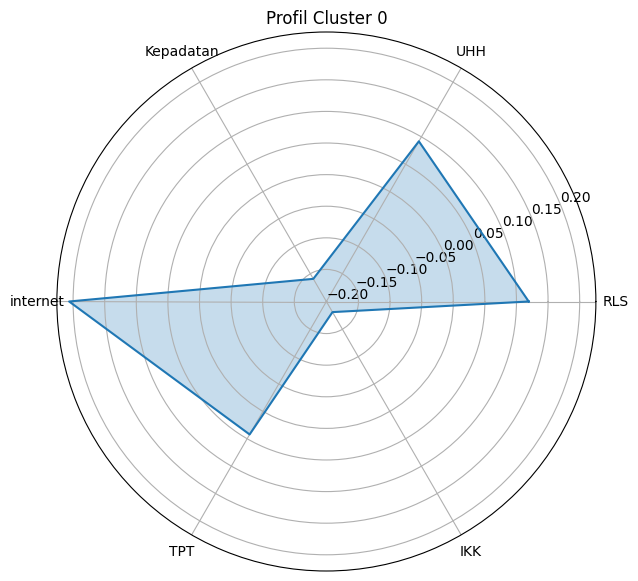

In [ ]:
fig, ax = plt.subplots(
    figsize=(7,7),
    subplot_kw=dict(polar=True)
)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title('Profil Cluster 0')

plt.show()

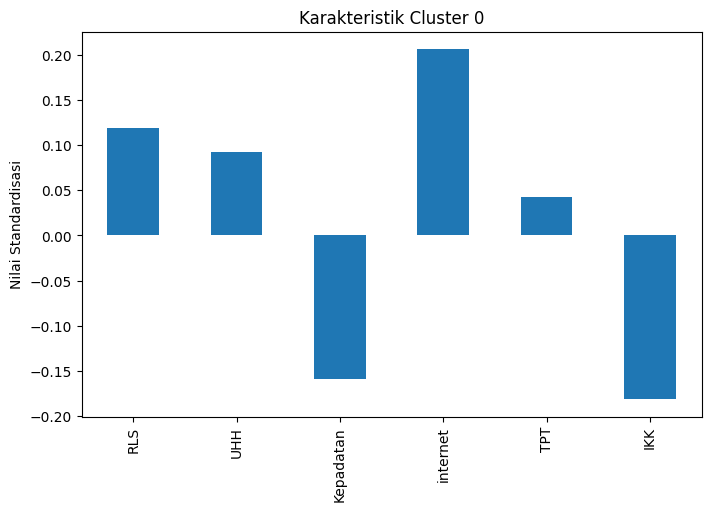

In [ ]:
scaled_mean.loc[0].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Karakteristik Cluster 0')
plt.ylabel('Nilai Standardisasi')
plt.show()

Cluster 0 (Daerah Berkembang dan Relatif Stabil)

Pendidikan (rata rata lama sekolah) berada di atas rata-rata, umur harapan hidup cukup tinggi, kepadatan penduduk tidak ekstrem, akses internet tinggi, tingkat pengangguran moderat, dan kemiskinan relatif rendah. Mayoritas provinsi di Indonesia masuk ke dalam cluster ini.

Cluster ini menunjukkan wilayah yang telah memiliki akses pendidikan cukup baik, mampu memanfaatkan teknologi digital, serta memiliki kualitas SDM yang berkembang. Akses internet yang tinggi menunjukkan potensi besar terhadap implementasi pembelajaran digital dan pengembangan literasi teknologi. Namun, tingkat pengangguran pada cluster ini masih moderat yang artinya kualitas pendidikan belum sepenuhnya selaras dengan kebutuhan dunia kerja, terutama dalam menghadapi era transformasi digital menuju Indonesia Emas 2045.

Cluster ini dapat dianggap sebagai kelompok transisi menuju pendidikan maju berbasis digital karena wilayah dalam cluster ini memiliki fondasi SDM yang cukup kuat tetapi masih memerlukan kualitas pendidikan dan keterampilan abad ke-21.

## Cluster 1 (Tertinggal)

In [ ]:
cluster_1 = data[data['Cluster'] == 1]
cluster_1

,Provinsi/Kabupaten/Kota/Indonesia,RLS,UHH,Kepadatan,internet,TPT,IKK,Cluster
35,PAPUA TENGAH,6.13,68.38,24,36.08,3.62,2.89,1
36,PAPUA PEGUNUNGAN,4.30,67.55,29,12.15,1.68,1.71,1


In [ ]:
labels = scaled_mean.columns
values = scaled_mean.loc[1].values.flatten().tolist()
values += values[:1]

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]

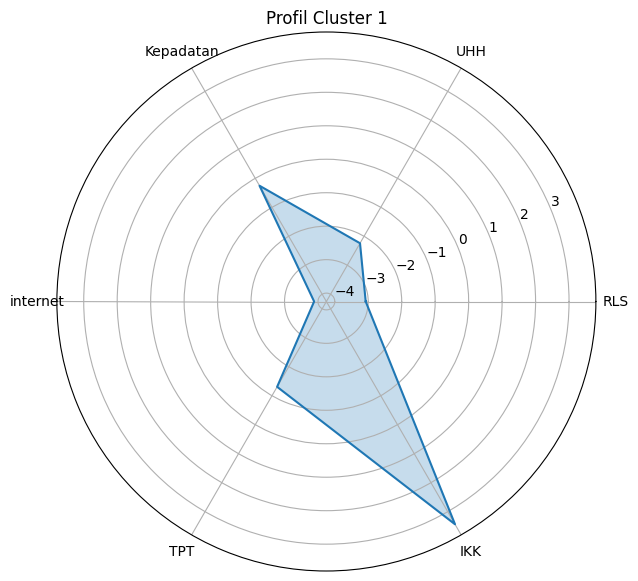

In [ ]:
fig, ax = plt.subplots(
    figsize=(7,7),
    subplot_kw=dict(polar=True)
)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title('Profil Cluster 1')

plt.show()

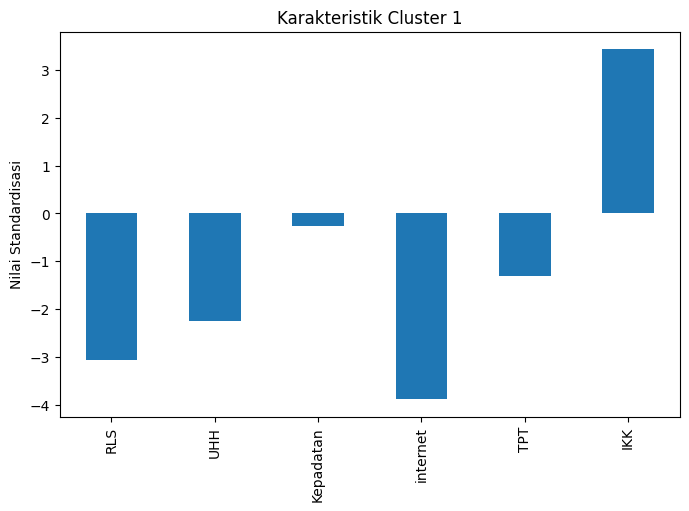

In [ ]:
scaled_mean.loc[1].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Karakteristik Cluster 1')
plt.ylabel('Nilai Standardisasi')
plt.show()

Cluster 1 (Daerah Tertinggal dan Rentan)

Pendidikan (rata rata lama sekolah) sangat rendah, umur harapan hidup rendah, akses internet sangat rendah, dan kemiskinan sangat tinggi, dan kepadatan rendah. Cluster ini merupakan daerah dengan keterbatasan akses pembangunan dan infrastruktur, akses pendidikan rendah, kesenjangan digital tinggi dan tingkat kemiskinan berat sehingga cluster ini harus menjadi prioritas utama Indonesia Emas 2045.

Cluster ini menunjukkan wilayah yang masih mengalami keterbatasan akses pendidikan, kualitas SDM yang rendah, dan minimnya dukungan infrastruktur digital. Rendahnya akses internet menjadi hambatan besar dalam pemerataan pendidikan, pembelajaran digital, dan akses informasi. Tingginya indeks keparahan kemiskinan juga memperlihatkan bahwa faktor ekonomi masih menjadi penghambat utama peningkatan kualitas pendidikan.

Cluster ini dapat dianggap sebagai wilayah tertinggal dan rentan, sehingga harus menjadi prioritas pembangunan pendidikan menuju Indonesia Emas 2045. Tanpa intervensi yang serius, kesenjangan pendidikan antarwilayah akan semakin besar dan bonus demografi berpotensi tidak dimanfaatkan secara optimal.

## Cluster 2 (Maju)

In [ ]:
cluster_2 = data[data['Cluster'] == 2]
cluster_2

,Provinsi/Kabupaten/Kota/Indonesia,RLS,UHH,Kepadatan,internet,TPT,IKK,Cluster
9,DKI JAKARTA,11.59,76.27,16155,98.18,6.05,0.1,2


In [ ]:
labels = scaled_mean.columns
values = scaled_mean.loc[2].values.flatten().tolist()
values += values[:1]

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]

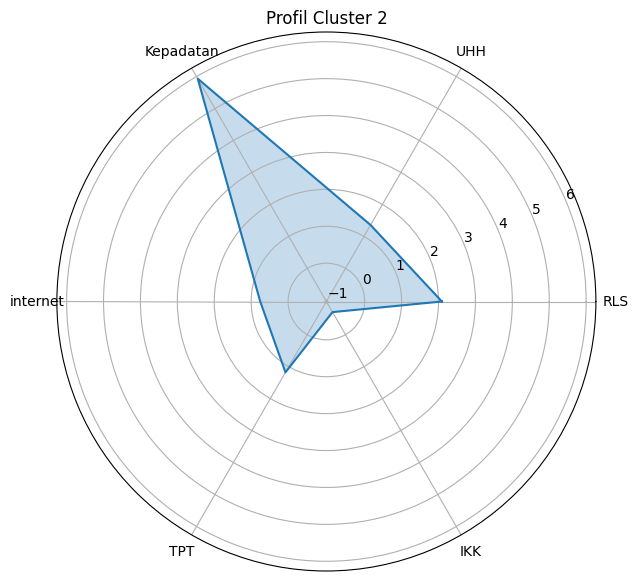

In [ ]:
fig, ax = plt.subplots(
    figsize=(7,7),
    subplot_kw=dict(polar=True)
)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title('Profil Cluster 2')

plt.show()

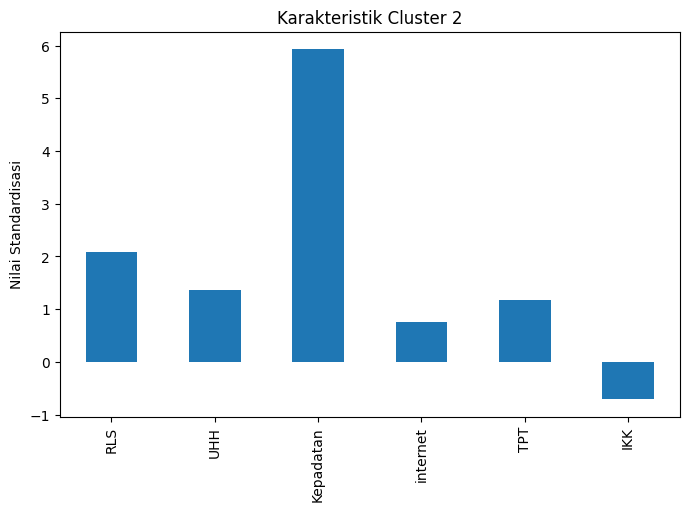

In [ ]:
scaled_mean.loc[2].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Karakteristik Cluster 2')
plt.ylabel('Nilai Standardisasi')
plt.show()

Cluster 2 (Daerah Metropolitan dan Sangat Maju)

Pendidikan (rata rata lama sekolah) sangat tinggi, umur harapan hidup tinggi, akses internet tinggi, dan kemiskinan sangat rendah. Namun pada cluster ini ditemukan bahwa kepadatan penduduk sangat ekstrem dan tingkat pengangguran juga paling tinggi dari ketiga cluster. Cluster ini dapat menjadi motor utama Indonesia Emas 2045.

Cluster ini menunjukkan wilayah dengan kualitas pendidikan paling maju, transformasi digital paling berkembang, dan kesiapan SDM terbaik dalam menghadapi era modern. Aksses internet yang hampir merata menunjukkan lingkungan pendidikan digital telah berkembang sangat baik. Namun, tingginya pengangguran menunjukkan bahwa persaingan kerja di wilayah ini sangat ketat sehingga pendidikan tidak hanya dituntut meningkatkan akses, tetapi juga relevansi terhadap dunia kerja.

Cluster ini dapat dianggap sebagai wilayah Metropolitan dan sangat maju atau dengan kata lain pusat penggerak pendidikan dan transformasi digital nasional. Wilayah dalam cluster ini berpotensi menjadi pusat inovasi pendidikan, pengembangan teknologi, dan model pendidikan masa depan Indonesia.